In [ ]:
#Dataset 1
import pandas as pd
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('Scenario-A-merged_5s.csv')

df.dropna(inplace=True)

df = df.replace([np.inf, -np.inf], np.nan).dropna()
source_ip_frequency = df['Source IP'].value_counts()
destination_ip_frequency = df[' Destination IP'].value_counts()

df['Source IP'] = df['Source IP'].map(source_ip_frequency)
df[' Destination IP'] = df[' Destination IP'].map(destination_ip_frequency)
df_target=df['label']
df.drop(['label'], axis=1, inplace=True)

print(df.describe()) #to summarize statistics
print(df.info()) #to print info about dataset

train, test = train_test_split(df, test_size=0.2, shuffle=True)

          Source IP   Source Port   Destination IP   Destination Port  \
count  84187.000000  84187.000000     84187.000000       84187.000000   
mean    5031.855476  36550.228301      3063.709920       13160.176868   
std     3609.622725  21514.235930      3172.777986       19548.441624   
min        1.000000     21.000000         1.000000          21.000000   
25%     2113.000000  15685.000000       252.000000         137.000000   
50%     4708.000000  42382.000000      1966.000000         443.000000   
75%     6311.000000  54420.000000      4968.000000       19302.000000   
max    10472.000000  65534.000000      9916.000000       65514.000000   

           Protocol   Flow Duration   Flow Bytes/s   Flow Packets/s  \
count  84187.000000    8.418700e+04   8.418700e+04     8.418700e+04   
mean      11.709254    1.976607e+06   2.693915e+05     2.767573e+03   
std        5.496051    2.143445e+06   5.147994e+06     4.374423e+04   
min        6.000000    1.000000e+00   0.000000e+00     4.0

In [ ]:
#Dataset 1 Binary Naive Bayes CLASSIFIER Minibatch K-Means
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from itertools import product
import numpy as np

k = 4
batch_size = 100
max_iter = 100

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

priors_list = [None,[0.1, 0.2, 0.3, 0.4], [0.2, 0.2, 0.3, 0.3], [0.25, 0.25, 0.25, 0.25]]
var_smoothing_list = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for priors, var_smoothing in product(priors_list, var_smoothing_list):
    a += 1
    print(a)

    nb_classifier = GaussianNB(priors=priors, var_smoothing=var_smoothing)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):
        train_labels = minibatch_kmeans.fit_predict(train.iloc[train_index])
        test_labels = minibatch_kmeans.predict(train.iloc[test_index])
        nb_classifier.fit(train.iloc[train_index], train_labels)
        predictions = nb_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'priors': priors, 'var_smoothing': var_smoothing}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

3


...

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

20


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Best hyperparameters: {'priors': None, 'var_smoothing': 1e-05}
Best accuracy: 0.9607864202232264


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Accuracy of Naive Bayes Classifier with Minibatch K-means cluster labels: 0.9679296828601972
Precision: 0.970782627133395
Recall: 0.9679296828601972
F1-score: 0.9685831002121156
Confusion Matrix:
 [[9871  395   42    0]
 [  26 5697   41    5]
 [   0    0  206   14]
 [   0    0   17  524]]


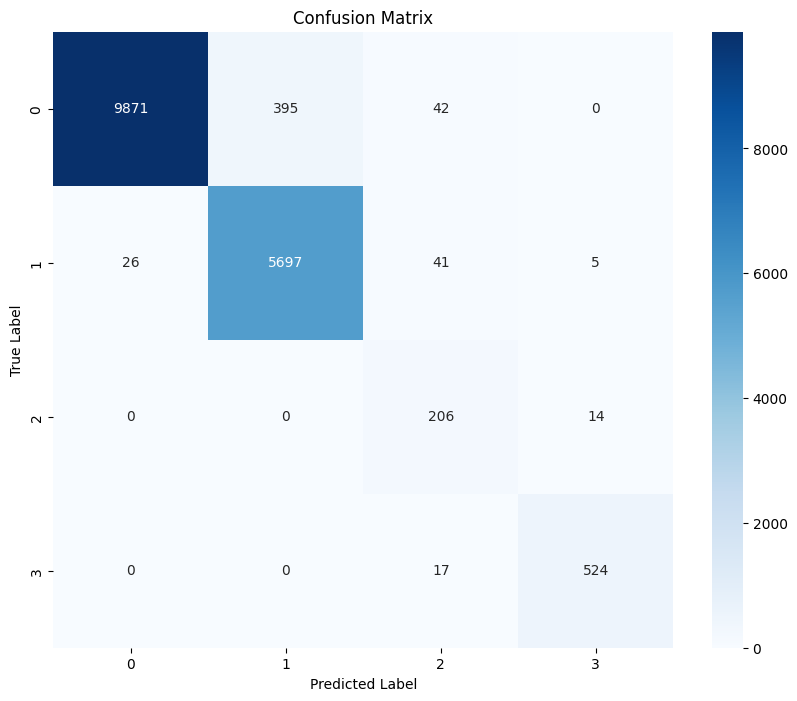

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression

k=4
batch_size=100
max_iter=100

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

train_labels = minibatch_kmeans.fit_predict(train)
test_labels = minibatch_kmeans.predict(test)


priors=None
var_smoothing=1e-05
nb_classifier = GaussianNB(priors=priors, var_smoothing=var_smoothing)

nb_classifier.fit(train, train_labels)

predictions = nb_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of Naive Bayes Classifier with Minibatch K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
#Dataset 1 Binary Naive Bayes CLASSIFIER GMM
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from itertools import product
import numpy as np
from sklearn.mixture import GaussianMixture

n_components=4
covariance_type='tied'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)

priors_list = [None, [0.1, 0.2, 0.3, 0.4], [0.2, 0.2, 0.3, 0.3], [0.25, 0.25, 0.25, 0.25]]
var_smoothing_list = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for priors, var_smoothing in product(priors_list, var_smoothing_list):
    a += 1
    print(a)

    nb_classifier = GaussianNB(priors=priors, var_smoothing=var_smoothing)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):
        train_labels = gmm.fit_predict(train.iloc[train_index])
        test_labels = gmm.predict(train.iloc[test_index])
        nb_classifier.fit(train.iloc[train_index], train_labels)
        predictions = nb_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'priors': priors, 'var_smoothing': var_smoothing}
print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
Best hyperparameters: {'priors': None, 'var_smoothing': 1e-09}
Best accuracy: 0.9617812455371274


Accuracy of Naive Bayes Classifier with Minibatch GMM cluster labels: 0.9676327354792731
Precision: 0.9699161622928515
Recall: 0.9676327354792731
F1-score: 0.9679384617903734
Confusion Matrix:
 [[9815    4  493    3]
 [   0    2    0    0]
 [  18    0 5727   27]
 [   0    0    0  749]]


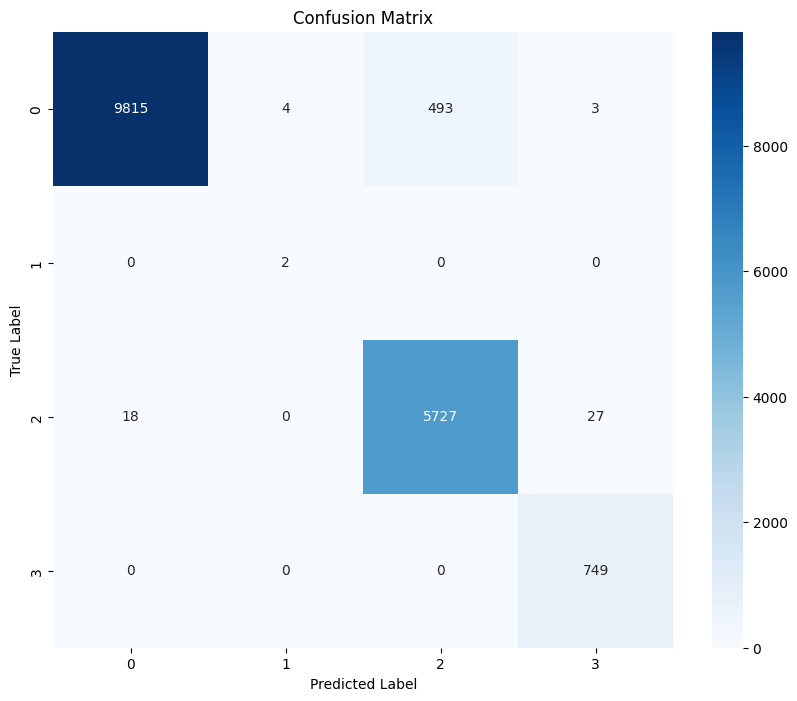

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression


n_components=4
covariance_type='tied'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)

train_labels = gmm.fit_predict(train)
test_labels =gmm.predict(test)


priors=None
var_smoothing=1e-09
nb_classifier = GaussianNB(priors=priors, var_smoothing=var_smoothing)

nb_classifier.fit(train, train_labels)
predictions = nb_classifier.predict(test)
accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of Naive Bayes Classifier with Minibatch GMM cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#Dataset 1 Binary Naive Bayes CLASSIFIER K-Means
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from itertools import product
import numpy as np
from sklearn.mixture import GaussianMixture

k = 5
init_type = 'k-means++'
max_iter = 200

kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)

priors_list = [None, [0.1, 0.2, 0.3, 0.4], [0.2, 0.2, 0.3, 0.3], [0.25, 0.25, 0.25, 0.25]]
var_smoothing_list = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for priors, var_smoothing in product(priors_list, var_smoothing_list):
    a += 1
    print(a)

    nb_classifier = GaussianNB(priors=priors, var_smoothing=var_smoothing)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):
        train_labels = kmeans.fit_predict(train.iloc[train_index])
        test_labels = kmeans.predict(train.iloc[test_index])
        nb_classifier.fit(train.iloc[train_index], train_labels)
        predictions = nb_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)
    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'priors': priors, 'var_smoothing': var_smoothing}
print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)

1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

3


...

19


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

20


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

Best hyperparameters: {'priors': None, 'var_smoothing': 1e-08}
Best accuracy: 0.9705859516391762


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Accuracy of Naive Bayes Classifier with K-means cluster labels: 0.8426178881102269
Precision: 0.9705278099771184
Recall: 0.8426178881102269
F1-score: 0.8952268583204761
Confusion Matrix:
 [[5651    0   62   12   48]
 [   0    2    0    0    0]
 [ 324    0 7727 2193    7]
 [   0    4    0   46    0]
 [   0    0    0    0  762]]


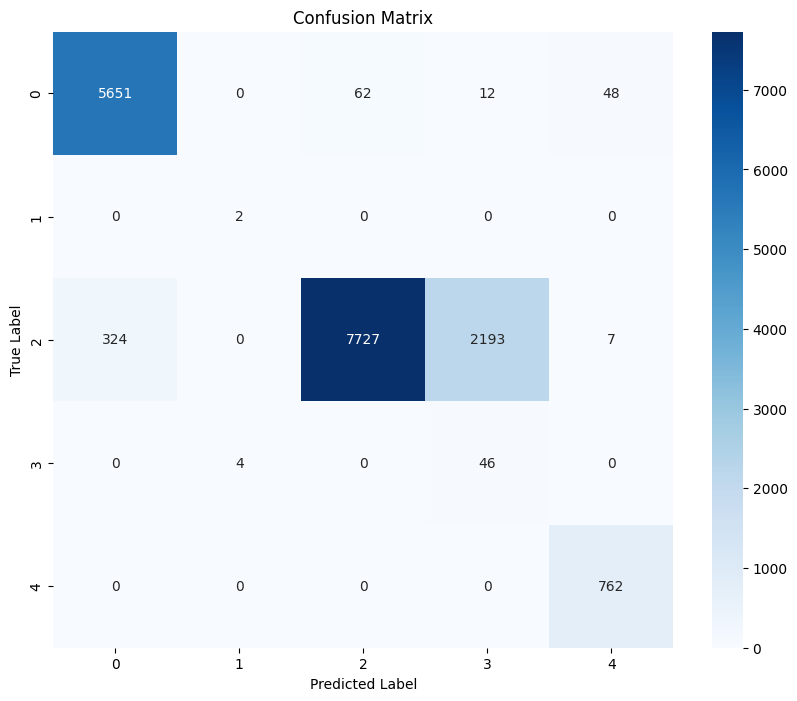

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression

k = 5
init_type = 'k-means++'
max_iter = 200

# Initialize KMeans clustering
kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)

train_labels = kmeans.fit_predict(train)
test_labels = kmeans.predict(test)

priors=None
var_smoothing=1e-08
nb_classifier = GaussianNB(priors=priors, var_smoothing=var_smoothing)

# Train the Random Forest Classifier on the training data with cluster labels
nb_classifier.fit(train, train_labels)

# Use the trained model to predict on test data
predictions = nb_classifier.predict(test)

# Calculate evaluation metrics
accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

# Print evaluation metrics
print("Accuracy of Naive Bayes Classifier with K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)
# Define custom class labels
class_labels = np.unique(np.concatenate((test_labels, predictions)))

# Plot heatmap for confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
#Dataset 1 Binary SVM CLASSIFIER Minibatch K-Means
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from itertools import product
import numpy as np
from sklearn.cluster import MiniBatchKMeans

k = 4
batch_size = 100
max_iter = 100

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

priors_list = [None, [0.1, 0.2, 0.3, 0.4], [0.2, 0.2, 0.3, 0.3]]
C_values = [0.001, 0.01, 0.1, 1, 10]

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for priors, C in product(priors_list, C_values):
    a += 1
    print(a)
    class_weights = 'balanced' if priors is None else {i: priors[i] for i in range(len(priors))}
    svm_classifier = SVC(C=C, kernel='linear', class_weight=class_weights)
    fold_accuracies = []
    for train_index, test_index in kf.split(train):
        train_labels = minibatch_kmeans.fit_predict(train.iloc[train_index])
        test_labels = minibatch_kmeans.predict(train.iloc[test_index])
        svm_classifier.fit(train.iloc[train_index], train_labels)
        predictions = svm_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)
    mean_accuracy = np.mean(fold_accuracies)
    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'priors': priors, 'C': C}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)

1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

3


...

14


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

15


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

Best hyperparameters: {'priors': [0.1, 0.2, 0.3, 0.4], 'C': 10}
Best accuracy: 0.999673343771667


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Accuracy of SVM Classifier with Minibatch K-means cluster labels: 0.9997624420952608
Precision: 0.9997627456117283
Recall: 0.9997624420952608
F1-score: 0.9997625007668566
Confusion Matrix:
 [[10232     0     0     2]
 [    1  4131     0     1]
 [    0     0   746     0]
 [    0     0     0  1725]]


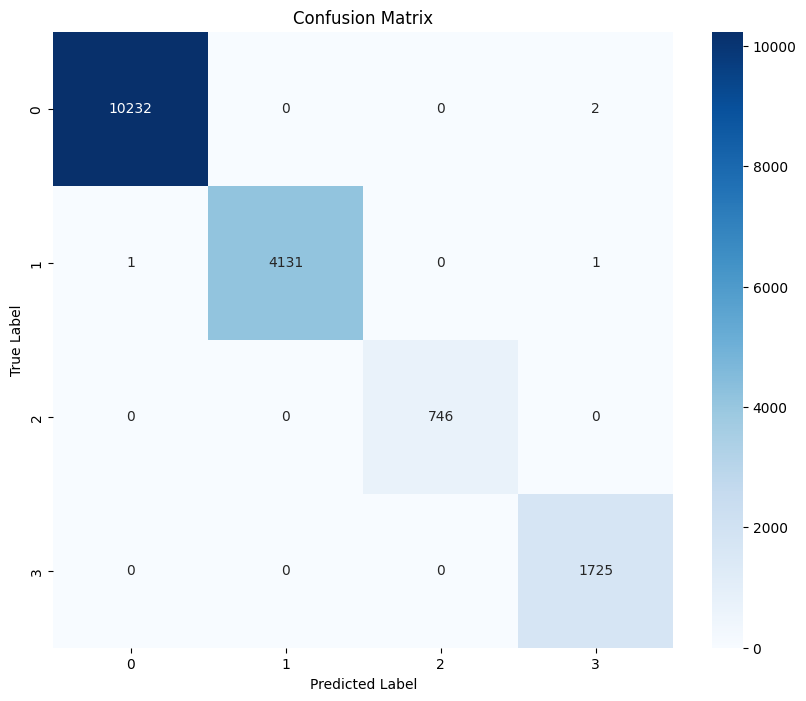

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression

k = 4
batch_size = 100
max_iter = 100

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

train_labels = minibatch_kmeans.fit_predict(train)
test_labels = minibatch_kmeans.predict(test)

C=10
priors=[0.1, 0.2, 0.3, 0.4]

class_weights = 'balanced' if priors is None else {i: priors[i] for i in range(len(priors))}
svm_classifier = SVC(C=C, kernel='linear', class_weight=class_weights)

svm_classifier.fit(train, train_labels)

predictions = svm_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of SVM Classifier with Minibatch K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
#CALISTIRAMADIM
#Dataset 1 Binary SVM CLASSIFIER GMM
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from itertools import product
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.mixture import GaussianMixture

n_components=4
covariance_type='tied'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)

priors_list = [None, [0.1, 0.2, 0.3, 0.4], [0.2, 0.2, 0.3, 0.3]]
C_values = [0.001, 0.01, 0.1, 1, 10]

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for priors, C in product(priors_list, C_values):
    a += 1
    print(a)

    class_weights = 'balanced' if priors is None else {i: priors[i] for i in range(len(priors))}

    svm_classifier = SVC(C=C, kernel='linear', class_weight=class_weights)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):
        train_labels = gmm.fit_predict(train.iloc[train_index])
        test_labels = gmm.predict(train.iloc[test_index])
        svm_classifier.fit(train.iloc[train_index], train_labels)
        predictions = svm_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'priors': priors, 'C': C}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)

1


In [ ]:
#Dataset 1 Binary SVM CLASSIFIER K-MEANS++
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from itertools import product
import numpy as np
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

k = 4
init_type = 'k-means++'
max_iter = 200

kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)

priors_list = [None, [0.1, 0.2, 0.3, 0.4], [0.2, 0.2, 0.3, 0.3]]
C_values = [0.001, 0.01, 0.1, 1, 10]

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for priors, C in product(priors_list, C_values):
    a += 1
    print(a)

    class_weights = 'balanced' if priors is None else {i: priors[i] for i in range(len(priors))}

    svm_classifier = SVC(C=C, kernel='linear', class_weight=class_weights)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):
        train_labels = kmeans.fit_predict(train.iloc[train_index])
        test_labels = kmeans.predict(train.iloc[test_index])
        predictions = svm_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'priors': priors, 'C': C}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

3


...

14


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

15


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

Best hyperparameters: {'priors': None, 'C': 0.001}
Best accuracy: 0.9998218251782545


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Accuracy of SVM Classifier with K-means cluster labels: 0.9995842736667062
Precision: 0.9995842884120104
Recall: 0.9995842736667062
F1-score: 0.9995842531378315
Confusion Matrix:
 [[  758     0     0     1     0]
 [    0     1     0     0     0]
 [    0     0 10351     2     0]
 [    0     0     4  5719     0]
 [    0     0     0     0     2]]


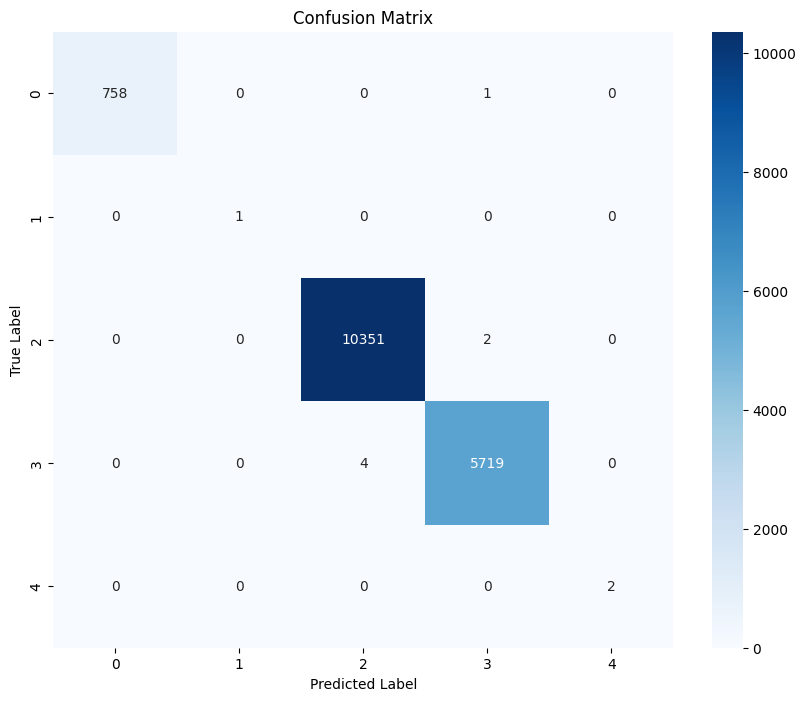

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression


k = 5
init_type = 'k-means++'
max_iter = 200

kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)

train_labels = kmeans.fit_predict(train)
test_labels = kmeans.predict(test)

C=10
priors=[0.1, 0.2, 0.3, 0.4]

class_weights = 'balanced' if priors is None else {i: priors[i] for i in range(len(priors))}
svm_classifier = SVC(C=C, kernel='linear', class_weight=class_weights)

svm_classifier.fit(train, train_labels)

predictions = svm_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of SVM Classifier with K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)
class_labels = np.unique(np.concatenate((test_labels, predictions)))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
#Datset 1 Binary XGBOOST CLASSIFIER Minibatch K-Means
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score
from sklearn.cluster import MiniBatchKMeans
from itertools import product
import numpy as np

k = 4
batch_size = 100
max_iter = 100

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

param_grid = {
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 300],
    'gamma': [0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for params in product(*param_grid.values()):
    a += 1
    print(a)

    max_depth, learning_rate, n_estimators, gamma, subsample, colsample_bytree = params

    xgb_classifier = xgb.XGBClassifier(max_depth=max_depth, learning_rate=learning_rate,
                                       n_estimators=n_estimators, gamma=gamma,
                                       subsample=subsample, colsample_bytree=colsample_bytree,
                                       random_state=42)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):
        train_labels = minibatch_kmeans.fit_predict(train.iloc[train_index])
        test_labels = minibatch_kmeans.predict(train.iloc[test_index])
        xgb_classifier.fit(train.iloc[train_index], train_labels)
        predictions = xgb_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)
    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'max_depth': max_depth, 'learning_rate': learning_rate,
                       'n_estimators': n_estimators, 'gamma': gamma,
                       'subsample': subsample, 'colsample_bytree': colsample_bytree}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)

1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

3


...

63


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

64


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

Best hyperparameters: {'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 100, 'gamma': 0.2, 'subsample': 0.8, 'colsample_bytree': 0.8}
Best accuracy: 0.9984558024109145


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Accuracy of XGBoost Classifier with Minibatch K-means cluster labels: 0.9980995367620857
Precision: 0.9981013724290333
Recall: 0.9980995367620857
F1-score: 0.9981001247300217
Confusion Matrix:
 [[ 4122     3     0    12]
 [    2 10126     0     4]
 [    0     0   726     0]
 [    7     4     0  1832]]


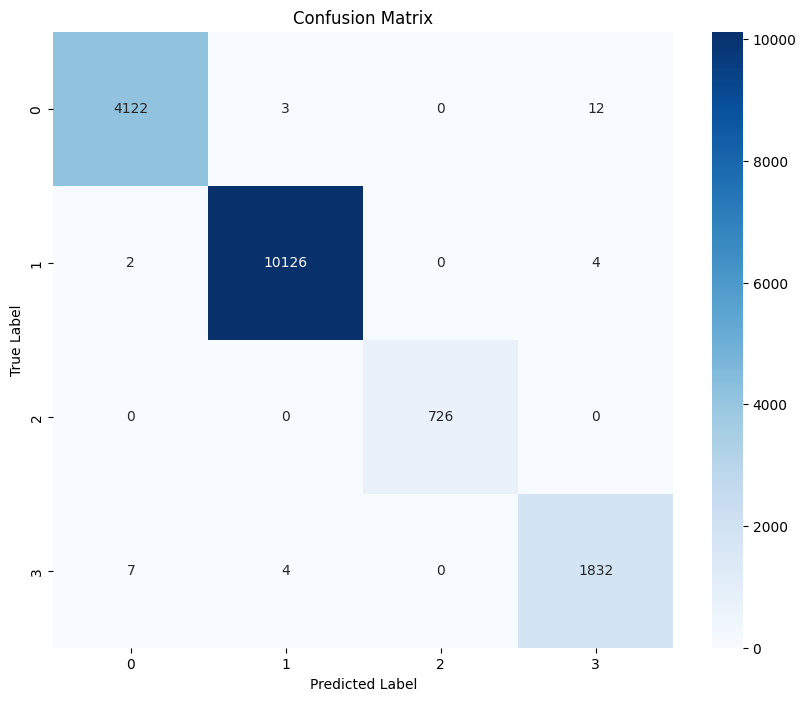

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import xgboost as xgb
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import MiniBatchKMeans

k = 4
batch_size = 100
max_iter = 100

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

train_labels = minibatch_kmeans.fit_predict(train)
test_labels = minibatch_kmeans.predict(test)

max_depth=6
learning_rate=0.1
n_estimators=100
gamma=0.2
subsample= 0.8
colsample_bytree=0.8

xgb_classifier = xgb.XGBClassifier(max_depth=max_depth, learning_rate=learning_rate,
                                       n_estimators=n_estimators, gamma=gamma,
                                       subsample=subsample, colsample_bytree=colsample_bytree,
                                       random_state=42)

xgb_classifier.fit(train, train_labels)
predictions = xgb_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of XGBoost Classifier with Minibatch K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#Datset 1 Binary XGBOOST CLASSIFIER K-Means
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score
from sklearn.cluster import MiniBatchKMeans
from itertools import product
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

k = 5
init_type = 'k-means++'
max_iter = 200

kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)

param_grid = {
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 300],
    'gamma': [0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for params in product(*param_grid.values()):
    a += 1
    print(a)

    max_depth, learning_rate, n_estimators, gamma, subsample, colsample_bytree = params
    xgb_classifier = xgb.XGBClassifier(max_depth=max_depth, learning_rate=learning_rate,
                                       n_estimators=n_estimators, gamma=gamma,
                                       subsample=subsample, colsample_bytree=colsample_bytree,
                                       random_state=42)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):

        train_labels = kmeans.fit_predict(train.iloc[train_index])
        test_labels = kmeans.predict(train.iloc[test_index])
        xgb_classifier.fit(train.iloc[train_index], train_labels)
        predictions = xgb_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'max_depth': max_depth, 'learning_rate': learning_rate,
                       'n_estimators': n_estimators, 'gamma': gamma,
                       'subsample': subsample, 'colsample_bytree': colsample_bytree}
print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)

1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

3


...

63


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

64


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

Best hyperparameters: {'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 300, 'gamma': 0.2, 'subsample': 0.8, 'colsample_bytree': 1.0}
Best accuracy: 0.9987676163411454


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Accuracy of XGBoost Classifier with K-means cluster labels: 0.9988715999524884
Precision: 0.9988502668512538
Recall: 0.9988715999524884
F1-score: 0.9988567891395558
Confusion Matrix:
 [[ 5808     0     0     8     0]
 [    0     2     0     0     0]
 [    1     0   741     0     0]
 [    4     0     0 10259     2]
 [    0     0     0     4     9]]


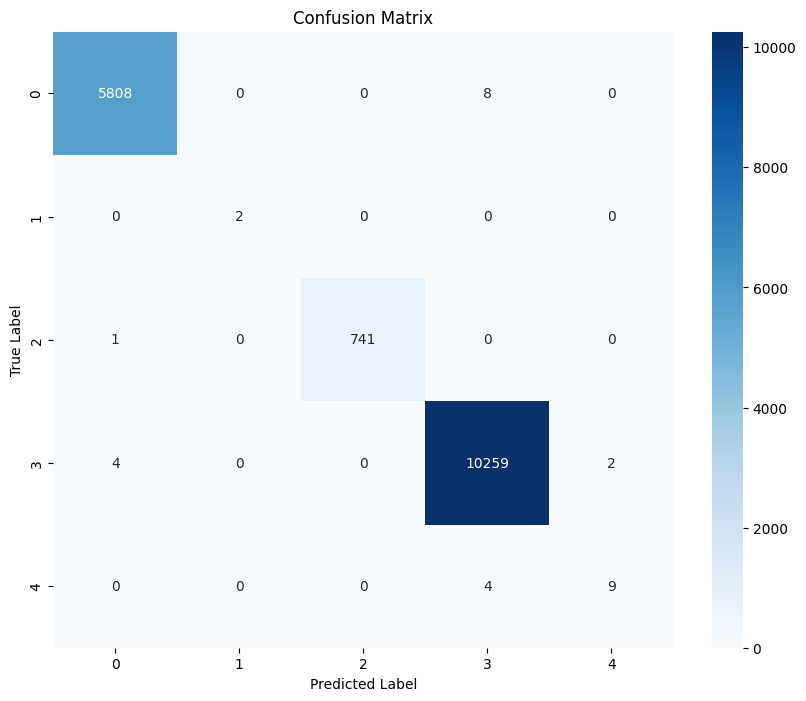

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression

k = 5
init_type = 'k-means++'
max_iter = 200

kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)

train_labels = kmeans.fit_predict(train)
test_labels = kmeans.predict(test)

max_depth=3
learning_rate=0.1
n_estimators=300
gamma=0.2
subsample= 0.8
colsample_bytree=1.0

xgb_classifier = xgb.XGBClassifier(max_depth=max_depth, learning_rate=learning_rate,
                                       n_estimators=n_estimators, gamma=gamma,
                                       subsample=subsample, colsample_bytree=colsample_bytree,
                                       random_state=42)
xgb_classifier.fit(train, train_labels)

predictions = xgb_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of XGBoost Classifier with K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#Datset 1 Binary XGBOOST CLASSIFIER GMM
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score
from sklearn.cluster import MiniBatchKMeans
from itertools import product
import numpy as np
from sklearn.mixture import GaussianMixture

n_components=4
covariance_type='tied'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)
param_grid = {
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 300],
    'gamma': [0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for params in product(*param_grid.values()):
    a += 1
    print(a)

    max_depth, learning_rate, n_estimators, gamma, subsample, colsample_bytree = params

    xgb_classifier = xgb.XGBClassifier(max_depth=max_depth, learning_rate=learning_rate,
                                       n_estimators=n_estimators, gamma=gamma,
                                       subsample=subsample, colsample_bytree=colsample_bytree,
                                       random_state=42)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):
        train_labels = gmm.fit_predict(train.iloc[train_index])
        test_labels = gmm.predict(train.iloc[test_index])
        xgb_classifier.fit(train.iloc[train_index], train_labels)
        predictions = xgb_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)
    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'max_depth': max_depth, 'learning_rate': learning_rate,
                       'n_estimators': n_estimators, 'gamma': gamma,
                       'subsample': subsample, 'colsample_bytree': colsample_bytree}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
Best hyperparameters: {'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 300, 'gamma': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}
Best accuracy: 0.9986636717501869


Accuracy of XGBoost Classifier with GMM cluster labels: 0.9985152630953795
Precision: 0.9985157073847257
Recall: 0.9985152630953795
F1-score: 0.998515036921663
Confusion Matrix:
 [[ 6539    18     0]
 [    7 10271     0]
 [    0     0     3]]


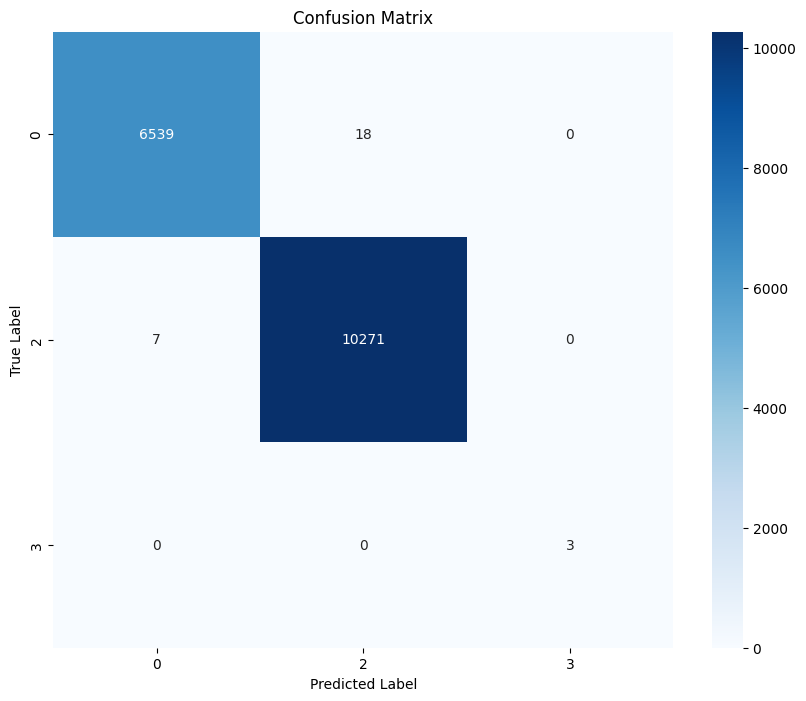

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression

n_components=4
covariance_type='tied'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)

train_labels = gmm.fit_predict(train)
test_labels = gmm.predict(test)

max_depth=3
learning_rate=0.1
n_estimators=300
gamma=0.1
subsample= 0.8
colsample_bytree=0.8

xgb_classifier = xgb.XGBClassifier(max_depth=max_depth, learning_rate=learning_rate,
                                       n_estimators=n_estimators, gamma=gamma,
                                       subsample=subsample, colsample_bytree=colsample_bytree,
                                       random_state=42)
xgb_classifier.fit(train, train_labels)

predictions = xgb_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of XGBoost Classifier with GMM cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import pandas as pd

score_data = {
    'Logistic Regression': [0.96543126],
    'Naive Bayes': [0.96792969],
    'Support Vector Machine': [0.99976244],
    'Decision Tree': [0.9973932],
    'Random Forest': [0.998218],
    'AdaBoost': [0.97132495],
    'XGBoost': [0.9988716],
}

df = pd.DataFrame(score_data)
df = df.transpose()
df.columns = ['Score']

print(df)

                           Score
Logistic Regression     0.965431
Naive Bayes             0.967930
Support Vector Machine  0.999762
Decision Tree           0.997393
Random Forest           0.998218
AdaBoost                0.971325
XGBoost                 0.998872
